# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

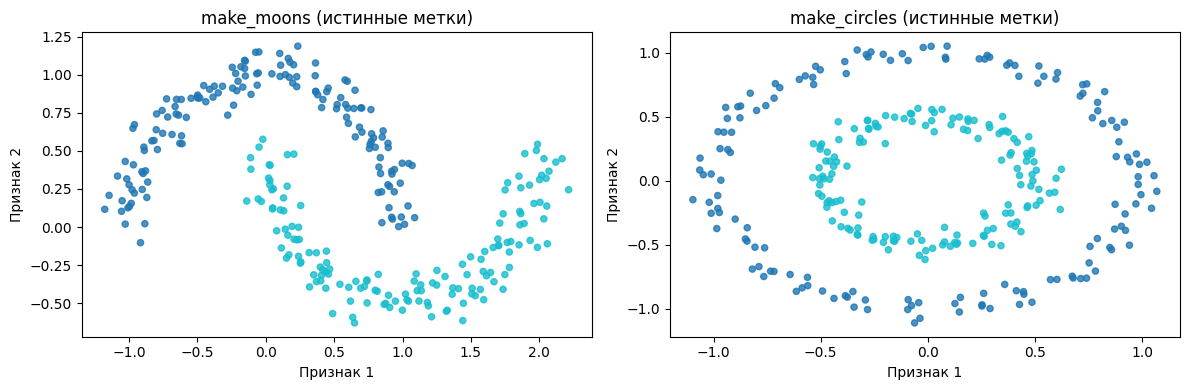

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

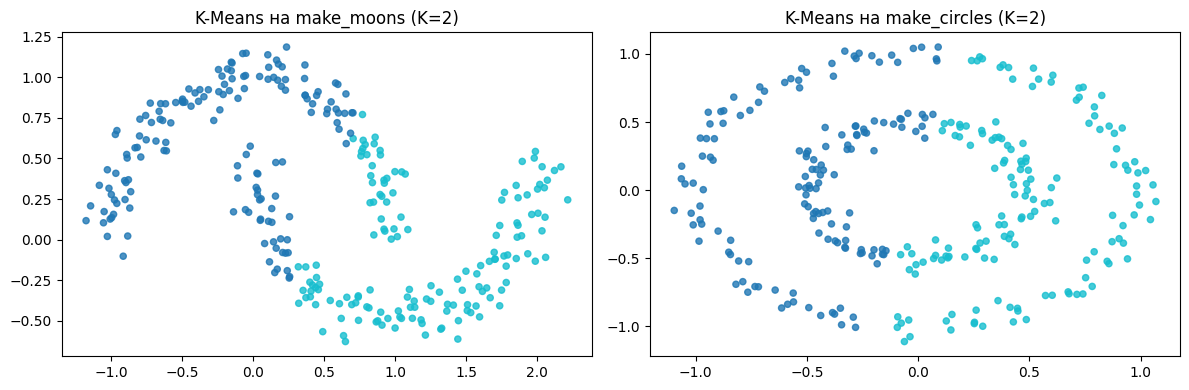

In [6]:
# Применим K-Means к этим датасетам
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2,random_state=RANDOM_STATE)  
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2,random_state=42)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Однозначно связано с Loss function, так как K-Means минимизирует сумму квадратов,то компактные сферические формы лучше всего минимизируют ошибку поэтому и разбиения получаются линейным, что не корректно на нелинейных данных в нашем случае

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

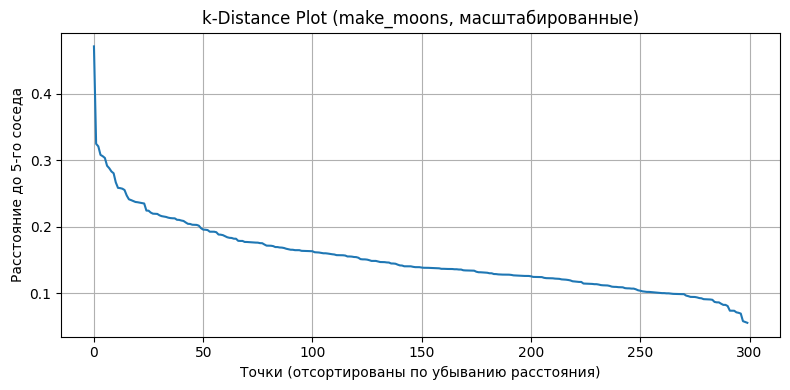

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [9]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)

distances, indices = nn.kneighbors(X_moons_scaled)

k_distances_moons = distances[:,-1]
k_distances_moons = np.sort(k_distances_moons)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

Локоть находится в диапазоне 0.25, до этого значения графика меняются довольно резко, а после более плавно, следовательно взяв эпсилон в этой области мы сможем отделить явный шум, где расстояние до соседов довольно велико, что видно по графику, и точки относящиеся к кластерам (расстояние до соседей не велико, что тоже видно по графику)

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

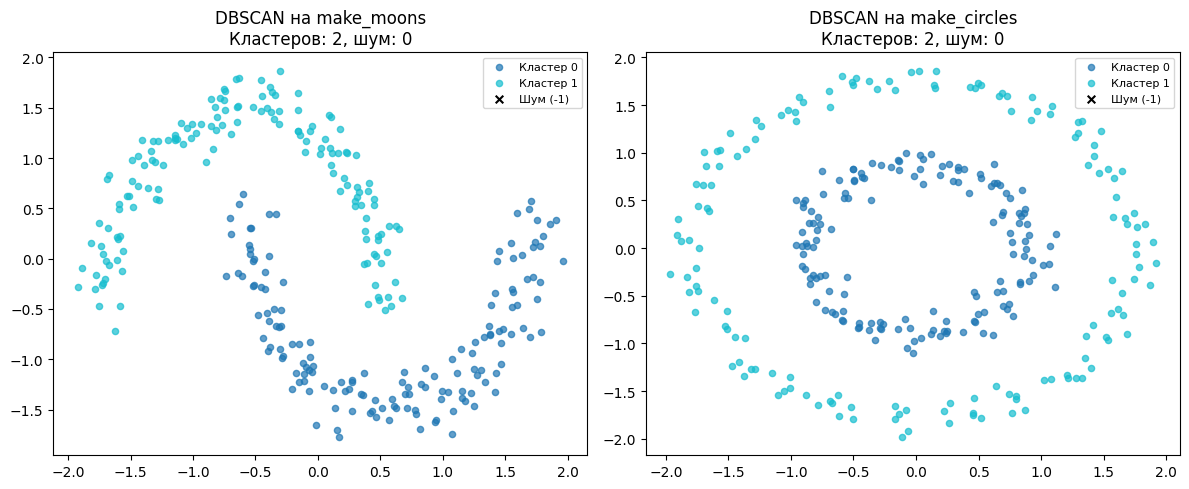

In [19]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

eps_moons = 0.27
eps_circle = 0.35

db_moons = DBSCAN(eps=eps_moons,min_samples=5) 
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=eps_circle,min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

Я чуть-чуть поигрался с эпсилонами для двух датасетов, и в итоге решил сделать для каждого свой. Первоначально взял 0.2 для обоих, что показало плохие резалты, было много шума и 18 КЛАСТЕРОВ на одном из датасетов, следовательно эпсилон был слишком маленьким. В конце как оптимальные взял 0.27 (для лун) и 0.35 (для колец)

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [21]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

kmeans_scaled = KMeans(n_clusters=2,random_state=RANDOM_STATE,n_init=10)
labels_kmeans_scaled = kmeans_scaled.fit_predict(X_moons_scaled)

score_kmeans = silhouette_score(X_moons_scaled,labels_kmeans_scaled)

mask_dbscan = labels_km_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[mask_dbscan],labels_db_moons[mask_dbscan])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

По метрикам лучший силуэт у K-Means, что пока не бьется об руку с визуальной частью. Это можно объяснить тем, что силуэт описывает то насколько точки близки к своему кластеру и далеки от другого, что по сути своей лучше подходит для выпуклых, примерно круглых кластеров, с которыми в свою очередь лучше всего работает K-means. Поэтому и получается, что визуально не линейные признаки лучше всего разделил DBSCAN, хотя по метрике получилось обратное, но опять связано это с тем как вычисляется силуэт. Поэтому для нелинейных кластеров силуэт как мера качества не особо объективен 

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

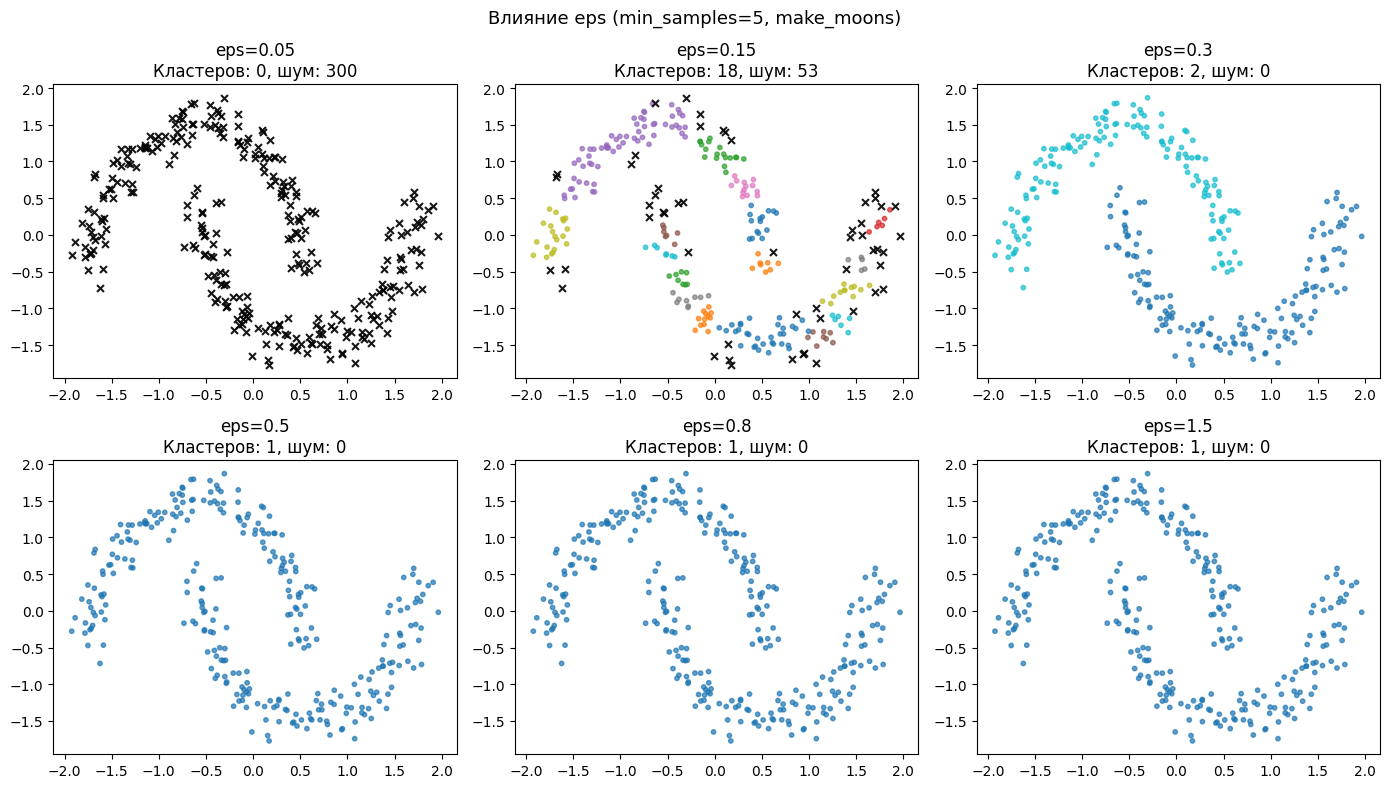

In [24]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    dbscan_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = dbscan_i.fit_predict(X_moons_scaled)

    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()

    noise_mask = labels_i == -1
    cluster_mask = labels_i != -1

    axes[i].scatter(
        X_moons_scaled[cluster_mask, 0],
        X_moons_scaled[cluster_mask, 1],
        c=labels_i[cluster_mask],
        cmap='tab10',
        s=10,
        alpha=0.7
    )

    axes[i].scatter(
        X_moons_scaled[noise_mask, 0],
        X_moons_scaled[noise_mask, 1],
        c='black',
        marker='x',
        s=25,
        alpha=0.9
    )

    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

Алгоритм нашел правильные кластеры при eps=0.2. Если эпсилон слишком мал, то почти все объекты классифицируются как шум, а при слишком большом все превращается в один большой кластер :(

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [27]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

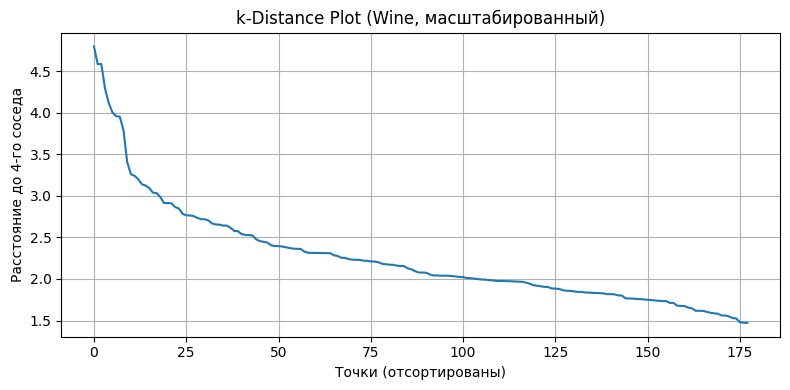

In [29]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

scaler_wines = StandardScaler()
X_wine_scaled = scaler_wines.fit_transform(X_wine) 
k_wine = 4

nn_wine = NearestNeighbors(n_neighbors=k_wine)
nn_wine.fit(X_wine_scaled)

distances,indices = nn_wine.kneighbors(X_wine_scaled)

k_dist_wine = distances[:,-1]
k_dist_wine = np.sort(k_dist_wine)[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.4

db_wine = DBSCAN(eps=eps_wine,min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_share_wine = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"eps : {eps_wine}")
print(f"Количество кластеров: {n_clusters_wine}")
print(f"Число шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_share_wine:.2%}")

mask_wine = labels_wine != -1

if n_clusters_wine > 1 :
    score_dbscan_wine = silhouette_score(
        X_wine_scaled[mask_wine],
        labels_wine[mask_wine]
    )
    print(f"Силуэт DBSCAN без шума: {score_dbscan_wine:.3f}")
else:
    score_dbscan_wine = None
    print("Силуэт не вычисляется: найдено меньше 2-х кластеров")

=== Результаты DBSCAN на Wine ===
eps : 2.4
Количество кластеров: 2
Число шумовых точек: 33
Доля шума: 18.54%
Силуэт DBSCAN без шума: 0.323


Конкретно явного локтя на графике не было, изначально взял 3.2, но все слилось в один кластер. Взяв "нижний локоть" на отметке 2.4 получил самую оптимальную оценку, где как минимум хотя бы два кластера и минимальная доля шума по отношению к другим eps с 2+ кластерами

---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [52]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

# маски для шумовых точек
noise_mask_wine = labels_wine == -1  
# признаки шумовых точек
X_wine_noise = X_wine[noise_mask_wine]

df_noise_wine = pd.DataFrame(X_wine_noise, columns=feature_names)

print("=== Средние значения признаков ===")
comparison = pd.DataFrame({
    'mean_all': df_wine.mean(),
    'mean_noise': df_noise_wine.mean()
})

comparison['difference'] = comparison['mean_all'] - comparison['mean_noise']
comparison['abs_difference'] = comparison['difference'].abs()

display(comparison.sort_values("abs_difference",ascending=False))

=== Средние значения признаков ===


,mean_all,mean_noise,difference,abs_difference
proline,746.893258,627.606061,119.287198,119.287198
magnesium,99.741573,102.878788,-3.137215,3.137215
alcalinity_of_ash,19.494944,20.527273,-1.032329,1.032329
color_intensity,5.058090,4.182727,0.875363,0.875363
alcohol,13.000618,12.530000,0.470618,0.470618
proanthocyanins,1.590899,1.871818,-0.280919,0.280919
malic_acid,2.336348,2.449697,-0.113349,0.113349
total_phenols,2.295112,2.385455,-0.090342,0.090342
hue,0.957449,0.998970,-0.041520,0.041520
od280/od315_of_diluted_wines,2.611685,2.594545,0.017140,0.017140


**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Шумовые точки отличаются тем, что лежат в более разряженных областях признакового пространства, насчет "плохих" я бы сказал, что все зависит от интерпретации, в данном случае эти точки можно выделить как вина с уникальным химическим составом

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Сравнение DBSCAN и K-Means на Wine
K-Means silhoutte: 0.285
DBSCAN silhouette без шума: 0.323


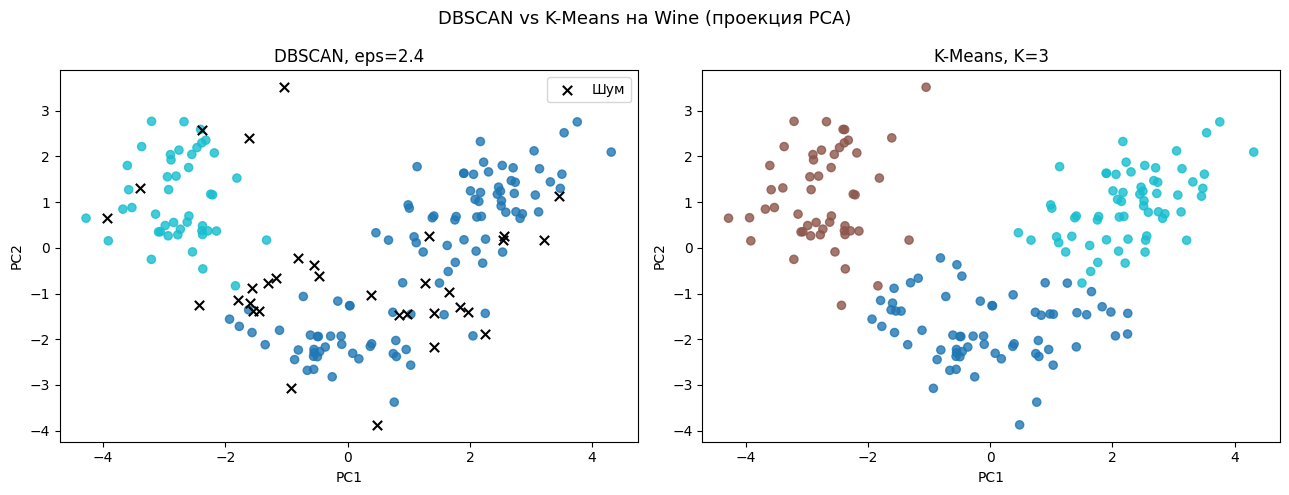

In [53]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

kmeans_wine = KMeans(n_clusters=3,random_state=RANDOM_STATE,n_init=10)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)

score_kmeans_wine = silhouette_score(X_wine_scaled,labels_km_wine)

print("Сравнение DBSCAN и K-Means на Wine")
print(f"K-Means silhoutte: {score_kmeans_wine:.3f}")

if score_dbscan_wine is not None:
    print(f"DBSCAN silhouette без шума: {score_dbscan_wine:.3f}")
else:
    print("DBSCAN silhouette не вычислен")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
noise_mask = labels_wine == -1
cluster_mask = labels_wine != -1

axes[0].scatter(
    X_wine_2d[cluster_mask, 0],
    X_wine_2d[cluster_mask, 1],
    c=labels_wine[cluster_mask],
    cmap="tab10",
    s=35,
    alpha=0.8
)

axes[0].scatter(
    X_wine_2d[noise_mask, 0],
    X_wine_2d[noise_mask, 1],
    c="black",
    marker="x",
    s=45,
    label="Шум"
)

axes[0].set_title(f"DBSCAN, eps={eps_wine}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# K-Means
axes[1].scatter(
    X_wine_2d[:, 0],
    X_wine_2d[:, 1],
    c=labels_km_wine,
    cmap="tab10",
    s=35,
    alpha=0.8
)

axes[1].set_title("K-Means, K=3")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

>  DBSCAN выигрывает, когда кластеры имеют нелинейную, невыпуклую форму, и когда в данных есть шумовые или выбросные точки. Ему не нужно заранее задавать число кластеров, он ищет плотные области данных.

**2. Когда K-Means предпочтительнее?**

> K-Means предпочтительнее, когда кластеры компактные, примерно сферические/выпуклые и хорошо разделяются вокруг центроидов. Также он удобен, когда заранее известно число кластеров и нужно распределить все объекты по группам без выделения шума.

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN использует расстояния между объектами, чаще всего евклидово расстояние. Если признаки имеют разные масштабы, признаки с большими численными значениями будут сильнее влиять на расстояние и фактически подавлять остальные. Масштабирование делает признаки сопоставимыми, поэтому параметр `eps` начинает иметь корректный смысл.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки в Wine — это объекты, которые находятся в менее плотных областях пространства признаков и не имеют достаточного числа близких соседей. Их не стоит автоматически считать ошибками или “плохими” данными. Скорее, это нетипичные или редкие образцы вина, которые DBSCAN не смог уверенно отнести к плотным группам.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Напрямую сравнивать силуэт DBSCAN и K-Means не всегда корректно. Силуэт лучше подходит для компактных выпуклых кластеров, поэтому может недооценивать нелинейные кластеры. Кроме того, у DBSCAN часть точек может быть помечена как шум и исключена из расчета, а K-Means назначает кластер каждой точке. Поэтому значения силуэта нужно интерпретировать вместе с визуализацией, числом шумовых точек и смыслом задачи.